# Regularized Regression — Notebook 04 · The Surge Engine and the Posterior

**Regularized Regression — From Likelihood to Lasso**

Covers **Task 5** (assemble a deployable pricing function with its policy layer) and the **Bonus** (the full Gaussian posterior, credible intervals and a predictive band).

---

### How to run this

Put `uber_surge_mumbai.csv` (and, for notebook 02, `new_city_features.csv` and
`new_city_truth.csv`) in a `data/` folder beside this notebook, or upload them to your
Colab session. If the files are missing, the next cell regenerates them from the same
seed, so nothing here breaks either way.

In [1]:
import os, sys, json, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True, linewidth=110)
pd.set_option('display.width', 120, 'display.max_columns', 30)

# --- a consistent look for every figure in this course -----------------------
plt.rcParams.update({
    'figure.figsize': (9, 4.6), 'figure.dpi': 110,
    'axes.grid': True, 'grid.alpha': .28, 'grid.linewidth': .7,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#c9cbc3', 'axes.labelcolor': '#4c514f',
    'axes.titlesize': 12, 'axes.titleweight': '600', 'axes.labelsize': 10,
    'xtick.color': '#767d7a', 'ytick.color': '#767d7a',
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'legend.frameon': False, 'legend.fontsize': 9,
    'font.size': 10, 'figure.facecolor': 'white', 'axes.facecolor': 'white',
})
C = {'ols': '#767d7a', 'ridge': '#2b5fa8', 'lasso': '#b4700c',
     'enet': '#5b4bb5', 'accent': '#1f6f5c', 'rose': '#b03a52'}

# Look in the usual places: beside the notebook, in ./data, or one level up
# (which is where the repo keeps them if you opened this from notebooks/).
SEARCH = ['data', '.', '../data', '..', '../../data']

def load(name):
    """Load a course CSV, regenerating it from the seed if it cannot be found."""
    for d in SEARCH:
        path = os.path.join(d, name)
        if os.path.exists(path):
            return pd.read_csv(path)
    for cand in ('scripts/make_data.py', 'make_data.py', '../scripts/make_data.py'):
        if os.path.exists(cand):
            subprocess.run([sys.executable, cand], check=True)
            return load(name)
    raise FileNotFoundError(
        f"{name} not found. Download it from the course site's Data page and put it "
        f"in a data/ folder beside this notebook.")

df = load('uber_surge_mumbai.csv')
print(f'{len(df)} trips, {df.shape[1]} columns')
df.head(3)

200 trips, 19 columns


,trip_id,zone,hour,is_peak,is_weekend,is_rain,is_event_nearby,is_airport_pickup,traffic_speed_kmph,drivers_available_500m,open_requests_500m,historical_demand,distance_km,time_min,base_fare_inr,surge_additive_inr,final_fare_inr,demand_supply_ratio,is_bad_weather
0,1,Powai,2,0,1,0,0,0,43.4,31,13,14.0,18.21,33.6,325.7,27.8,353.5,0.419,0
1,2,Lower Parel,18,1,0,1,1,0,22.8,6,46,46.2,15.06,42.7,306.1,150.0,456.1,7.667,1
2,3,Andheri East,15,0,0,0,1,0,47.3,17,25,26.4,3.24,7.8,94.5,65.7,160.2,1.471,0


In [2]:
# ---------------------------------------------------------------------------
# Conventions used throughout this course. Read these once; they save hours.
#
#   Objective (identical to sklearn's ElasticNet, including the 1/2n):
#       (1/2n)||y - Xw||^2  +  alpha*rho*||w||_1  +  (alpha*(1-rho)/2)*||w||^2
#
#   So the Ridge CLOSED FORM needs  n*alpha  where sklearn's Ridge takes alpha:
#       w = (X^T X + n*alpha*I)^-1 X^T y
#
#   Standardize on the TRAINING rows only, then apply that scaler to the test
#   rows. Split by time, never shuffled: trips 1-150 train, 151-200 test.
# ---------------------------------------------------------------------------
BASE8 = ['is_peak', 'is_rain', 'traffic_speed_kmph', 'drivers_available_500m',
         'is_event_nearby', 'is_airport_pickup', 'is_weekend', 'open_requests_500m']
SHORT = {'is_peak': 'is_peak', 'is_rain': 'is_rain',
         'traffic_speed_kmph': 'traffic_speed', 'drivers_available_500m': 'drivers_avail',
         'is_event_nearby': 'is_event', 'is_airport_pickup': 'is_airport',
         'is_weekend': 'is_weekend', 'open_requests_500m': 'open_requests',
         'is_bad_weather': 'is_bad_weather'}
N_TRAIN, SIGMA, TAU = 150, 10.0, 1.0

def split(frame, features):
    X = frame[features].to_numpy(float)
    y = frame['surge_additive_inr'].to_numpy(float)
    return X[:N_TRAIN], X[N_TRAIN:], y[:N_TRAIN], y[N_TRAIN:]

def standardize(Xtr, Xte):
    mu, sd = Xtr.mean(0), Xtr.std(0)
    sd = np.where(sd == 0, 1e-8, sd)
    return (Xtr - mu) / sd, (Xte - mu) / sd, mu, sd

def rmse(y, yhat):
    return float(np.sqrt(np.mean((y - yhat) ** 2)))

def r2(y, yhat):
    return float(1 - np.sum((y - yhat) ** 2) / np.sum((y - y.mean()) ** 2))

print('conventions loaded')

conventions loaded


In [3]:
def soft_threshold(rho, gamma):
    return np.sign(rho) * max(abs(rho) - gamma, 0.0)

def coordinate_descent(Z, y, alpha, l1_ratio=1.0, tol=1e-7, max_iter=3000):
    n, p = Z.shape
    w = np.zeros(p); l1, l2 = alpha * l1_ratio, alpha * (1 - l1_ratio)
    col_sq = (Z ** 2).sum(0) / n; r = y - Z @ w
    for sweep in range(max_iter):
        md_ = 0.0
        for j in range(p):
            rho = Z[:, j] @ (r + Z[:, j] * w[j]) / n
            new = soft_threshold(rho, l1) / (col_sq[j] + l2)
            d = new - w[j]
            if d != 0.0:
                r -= Z[:, j] * d; w[j] = new; md_ = max(md_, abs(d))
        if md_ < tol:
            break
    return w, sweep + 1

def kfold_cv(Z, y, k, fit):
    n = len(y); idx = np.arange(n); tot = 0.0
    for f in range(k):
        te = np.zeros(n, bool); te[idx[f::k]] = True
        yb = y[~te].mean()
        w = fit(Z[~te], y[~te] - yb)
        tot += np.sum((y[te] - (Z[te] @ w + yb)) ** 2)
    return float(np.sqrt(tot / n))

df['is_bad_weather'] = ((df.is_rain == 1) & (df.traffic_speed_kmph < 25)).astype(int)
FEATS = BASE8 + ['is_bad_weather']
Xtr, Xte, ytr, yte = split(df, FEATS)
Ztr, Zte, MU, SD = standardize(Xtr, Xte)
YBAR = ytr.mean()

# Tune by 5-fold CV on the training split, exactly as in notebook 03.
grid = np.logspace(-3, 2.2, 40)
scores = [kfold_cv(Ztr, ytr, 5, lambda Z, t, a=a: coordinate_descent(Z, t, a, 0.5)[0])
          for a in grid]
ALPHA = float(grid[int(np.argmin(scores))])
W, _ = coordinate_descent(Ztr, ytr - YBAR, ALPHA, 0.5)
print(f'Elastic Net, CV-tuned alpha = {ALPHA:.4f}')
print('test RMSE = Rs', round(rmse(yte, Zte @ W + YBAR), 2))

Elastic Net, CV-tuned alpha = 0.0215
test RMSE = Rs 12.92


## Task 5 — the pricing function

Note where the policy lives: **outside** the model. The regression estimates what the
market would bear; the cap and threshold are business decisions about what to charge.
Separate layers let you change the cap without retraining, and audit the two
independently.

In [4]:
CAP, THRESHOLD, MOVE_INCENTIVE = 150.0, 1.5, 50.0

def price(hour, is_rain, traffic, drivers, requests, distance_km,
          is_event=0, is_airport=0, is_weekend=0, cap=CAP, threshold=THRESHOLD):
    """Price one trip. Returns every intermediate quantity, not just the answer."""
    is_peak = int((8 <= hour <= 10) or (18 <= hour <= 21))
    bad_weather = int(is_rain == 1 and traffic < 25)
    x = np.array([is_peak, is_rain, traffic, drivers, is_event,
                  is_airport, is_weekend, requests, bad_weather], float)
    z = (x - MU) / SD
    raw = float(z @ W + YBAR)                      # ---- model layer ----
    ratio = requests / max(drivers, 1)             # ---- policy layer ----
    if ratio < threshold:
        surge, reason = 0.0, f'suppressed: demand/supply {ratio:.2f} < {threshold}'
    elif raw > cap:
        surge, reason = cap, f'clipped at the Rs {cap:.0f} cap'
    elif raw < 0:
        surge, reason = 0.0, 'model went negative, floored at zero'
    else:
        surge, reason = raw, 'within cap and above threshold'
    time_min = distance_km * 2 + (12 if is_peak else 0)
    base = 40 + 12 * distance_km + 2 * time_min
    return {'is_peak': is_peak, 'demand_supply_ratio': round(ratio, 3),
            'raw_model_output': round(raw, 2), 'surge': round(surge, 2),
            'policy': reason, 'base_fare': round(base, 2),
            'final_fare': round(base + surge, 2),
            'driver_should_move': surge > MOVE_INCENTIVE}

bkc = price(hour=19, is_rain=1, traffic=16, drivers=5, requests=25, distance_km=8.0)
for k, v in bkc.items():
    print(f'  {k:<22} {v}')

  is_peak                1
  demand_supply_ratio    5.0
  raw_model_output       153.61
  surge                  150.0
  policy                 clipped at the Rs 150 cap
  base_fare              192.0
  final_fare             342.0
  driver_should_move     True


> **Step 3 — what the ₹50 rule assumes.** "Reposition if the surge exceeds ₹50" assumes
> the driver's cost of a 3 km deadhead (fuel, time, the option value of staying put) is
> below ₹50, and that they will still be matched on arrival. Neither is modelled. The
> second matters: the probability of getting the trip falls as every other driver responds
> to the same signal.

## Step 4 — sweep the supply and look at the discontinuity

findfont: Failed to find font weight 600 for DejaVu Sans, now using 700.


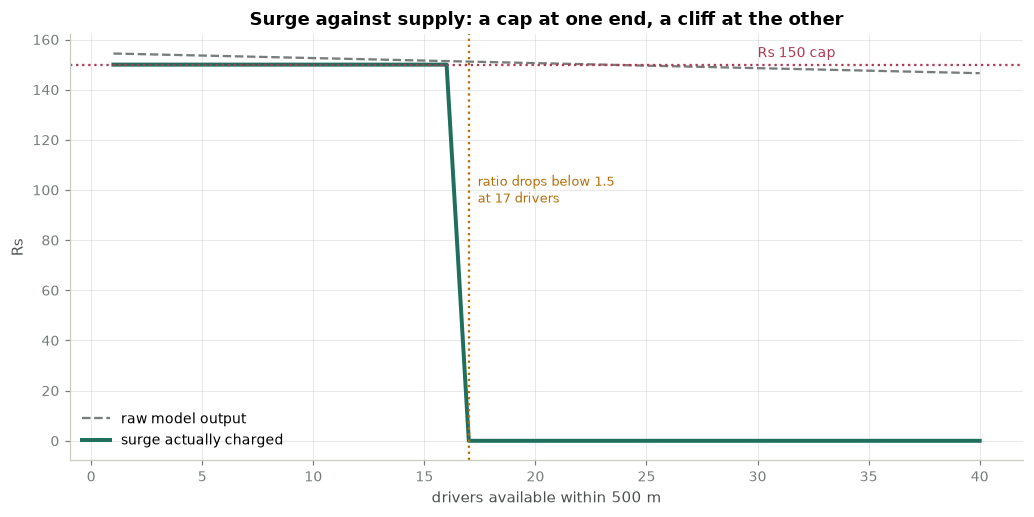

 drivers  demand_supply_ratio  raw_model_output  surge  final_fare
      15                1.667             151.6  150.0       342.0
      16                1.562             151.4  150.0       342.0
      17                1.471             151.2    0.0       192.0
      18                1.389             151.0    0.0       192.0


In [5]:
drivers_range = np.arange(1, 41)
sw = pd.DataFrame([price(19, 1, 16, int(d), 25, 8.0) for d in drivers_range])
sw['drivers'] = drivers_range

fig, ax = plt.subplots(figsize=(9.5, 4.8))
ax.plot(sw.drivers, sw.raw_model_output, '--', color=C['ols'],
        label='raw model output')
ax.plot(sw.drivers, sw.surge, lw=2.6, color=C['accent'], label='surge actually charged')
ax.axhline(CAP, color=C['rose'], ls=':', lw=1.5)
ax.text(30, CAP + 3, f'Rs {CAP:.0f} cap', color=C['rose'], fontsize=9)
cross = sw.loc[sw.surge == 0, 'drivers'].min()
ax.axvline(cross, color=C['lasso'], ls=':', lw=1.5)
ax.text(cross + 0.4, 95, f'ratio drops below {THRESHOLD}\nat {cross} drivers',
        color=C['lasso'], fontsize=8.6)
ax.set(xlabel='drivers available within 500 m', ylabel='Rs',
       title='Surge against supply: a cap at one end, a cliff at the other')
ax.legend()
plt.tight_layout(); plt.show()

print(sw.loc[sw.drivers.between(cross - 2, cross + 1),
             ['drivers', 'demand_supply_ratio', 'raw_model_output', 'surge',
              'final_fare']].to_string(index=False))

> **Write-up prompt.** One extra driver on the street moves the fare by the full surge
> amount. Two riders requesting the same trip thirty seconds apart can pay very different
> prices because of something neither of them can see. Is a step function the right
> policy? What would a smooth ramp cost you, and what would it buy? And note that the
> ratio is itself an *estimate* with uncertainty — which a hard threshold ignores entirely.
>
> **Look harder at the dashed line.** The raw model output is almost flat across the whole
> supply range: going from 1 driver to 40 barely moves it. That is a *modelling* failure,
> not a policy one. The data generating process contains a $50/(S+1)$ term — sharply
> non-linear in supply — and a model linear in `drivers_available` simply cannot represent
> it. Adding `1/(drivers+1)` as a feature is a one-line change; try it, report what happens
> to the sweep and to test RMSE, and note that no amount of regularization would have found
> this for you. Choosing the right features is still your job.

> **Step 5 — elasticity.** The data cannot answer it. Prices were set by a policy that
> responded to demand, so price and demand are simultaneously determined and any regression
> of demand on price is confounded. Identifying elasticity needs experimental variation:
> hold out a fraction of cell-buckets from the surge policy, or randomise the surge within
> a narrow band. Name the endogeneity; "we need more data" is not the answer.

---

## Bonus — the full Gaussian posterior

$$\Sigma = \left(\frac{X^\top X}{\sigma^2} + \frac{I}{\tau^2}\right)^{-1},
\qquad \mu = \frac{1}{\sigma^2}\Sigma X^\top y$$

with $\sigma = 10$, $\tau = 1$. The posterior *mean* should equal the ridge solution at
$\lambda = \sigma^2/\tau^2 = 100$ — because the mode of a Gaussian is its mean.

In [6]:
Xtr8, Xte8, ytr8, yte8 = split(df, BASE8)
Z8, Zt8, MU8, SD8 = standardize(Xtr8, Xte8)
yb8 = ytr8.mean(); yc8 = ytr8 - yb8
s2, t2 = SIGMA ** 2, TAU ** 2

Sigma = np.linalg.inv(Z8.T @ Z8 / s2 + np.eye(8) / t2)
mu_post = Sigma @ Z8.T @ yc8 / s2
sd_post = np.sqrt(np.diag(Sigma))

w_ridge100 = np.linalg.solve(Z8.T @ Z8 + (s2 / t2) * np.eye(8), Z8.T @ yc8)
print(f'max |posterior mean - ridge(lambda=100)| = '
      f'{np.max(np.abs(mu_post - w_ridge100)):.2e}   <- an identity, not an approximation')

post = pd.DataFrame({
    'feature': [SHORT[f] for f in BASE8],
    'mean': mu_post.round(2), 'sd': sd_post.round(2),
    'lo95': (mu_post - 1.96 * sd_post).round(2),
    'hi95': (mu_post + 1.96 * sd_post).round(2)})
post['covers_zero'] = post.lo95 * post.hi95 < 0
print('\n', post.to_string(index=False))

max |posterior mean - ridge(lambda=100)| = 1.15e-14   <- an identity, not an approximation

       feature   mean   sd   lo95   hi95  covers_zero
      is_peak  10.25 0.76   8.76  11.75        False
      is_rain   7.23 0.71   5.84   8.62        False
traffic_speed -12.02 0.78 -13.54 -10.50        False
drivers_avail  -6.12 0.76  -7.61  -4.63        False
     is_event   3.63 0.65   2.35   4.92        False
   is_airport   4.94 0.63   3.70   6.18        False
   is_weekend   0.73 0.66  -0.57   2.02         True
open_requests   6.50 0.74   5.05   7.94        False


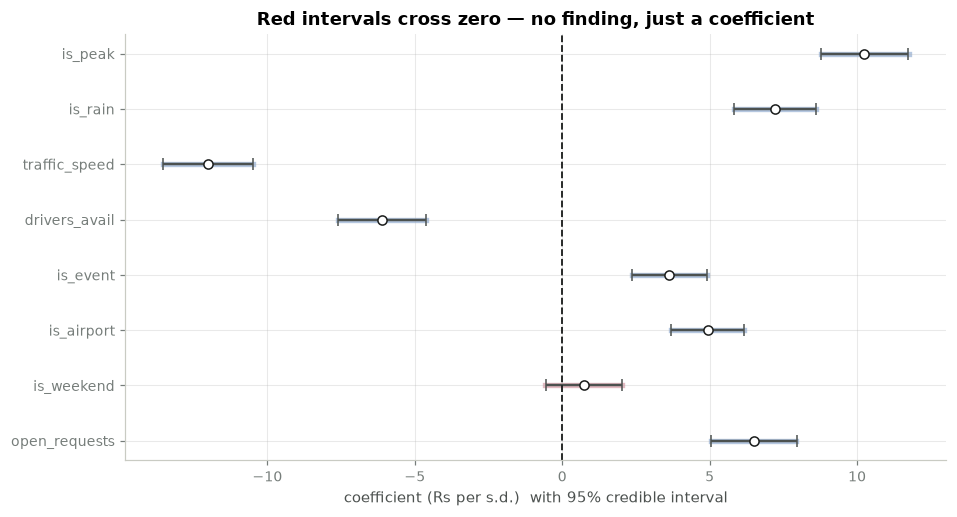

intervals covering zero: is_weekend


In [7]:
fig, ax = plt.subplots(figsize=(8.8, 4.8))
ypos = np.arange(len(post))[::-1]
colors = [C['rose'] if z else C['ridge'] for z in post.covers_zero]
ax.errorbar(post['mean'], ypos,
            xerr=1.96 * post['sd'], fmt='o', capsize=4, lw=1.6,
            ecolor='#4c514f', mfc='white', mec='#1b1d1c', ms=6)
for y_, m, lo, hi, col in zip(ypos, post['mean'], post.lo95, post.hi95, colors):
    ax.plot([lo, hi], [y_, y_], lw=3.5, color=col, alpha=.35, zorder=0)
ax.axvline(0, color='#1b1d1c', lw=1.2, ls='--')
ax.set_yticks(ypos); ax.set_yticklabels(post.feature)
ax.set(xlabel='coefficient (Rs per s.d.)  with 95% credible interval',
       title='Red intervals cross zero — no finding, just a coefficient')
plt.tight_layout(); plt.show()

print('intervals covering zero:',
      ', '.join(post.loc[post.covers_zero, 'feature']) or 'none')

## Predictive uncertainty for the BKC trip

In [8]:
x_star = np.array([1, 1, 16, 5, 0, 0, 0, 25], float)   # peak, rain, traffic 16, 5 drivers
z_star = (x_star - MU8) / SD8

pred = float(z_star @ mu_post + yb8)
var_w = float(z_star @ Sigma @ z_star)     # uncertainty about w
var_total = var_w + s2                     # + irreducible observation noise
sd_total = np.sqrt(var_total)

print(f'point estimate            : Rs {pred:.1f}')
print(f'variance from w           : {var_w:.2f}   ({100*var_w/var_total:.0f}% of total)')
print(f'irreducible noise         : {s2:.0f}   ({100*s2/var_total:.0f}% of total)')
print(f'\nquote to the rider        : Rs {pred:.0f} +/- Rs {sd_total:.0f}')
print(f'95% predictive interval   : [{pred-1.96*sd_total:.0f}, {pred+1.96*sd_total:.0f}]')
print(f'\nNote the upper end against the Rs {CAP:.0f} cap.')

point estimate            : Rs 139.3
variance from w           : 2.92   (3% of total)
irreducible noise         : 100   (97% of total)

quote to the rider        : Rs 139 +/- Rs 10
95% predictive interval   : [119, 159]

Note the upper end against the Rs 150 cap.


> **Step 5 — which term dominates?** Almost all the predictive variance is the irreducible
> $\sigma^2$, not uncertainty about $w$. Ten times more data would shrink the first term
> and leave the second untouched. A tighter quote needs a better model — the non-linear
> $50/(S+1)$ supply term, for instance — not more rows.
>
> **Step 6 — the sentence to refuse.** The upper end of that interval exceeds the ₹150 cap,
> so an honest interval promises a price the policy layer forbids. Refuse any phrasing that
> implies the rider could be charged above the cap, or that presents the point estimate as
> a guarantee. A subtler problem: showing a range invites riders to wait and re-request,
> which changes the demand the model was fitted on.

---

### Checklist

- [ ] `price()` returns every intermediate quantity, with policy outside the model
- [ ] BKC scenario reported in full; reposition decision justified
- [ ] Supply sweep plotted, with cap and threshold marked, and the cliff discussed
- [ ] Endogeneity named in the elasticity answer
- [ ] Posterior mean confirmed equal to ridge at $\lambda = 100$
- [ ] Credible intervals plotted; the interval covering zero identified
- [ ] Predictive variance decomposed, and the cap conflict noticed

**You now have everything for Deliverables 1–3.** Good luck.